In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (150, 4)


In [4]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original dimensions:", X.shape)
print("Reduced dimensions:", X_pca.shape)

Original dimensions: (150, 4)
Reduced dimensions: (150, 2)


In [5]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:",
      pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.72962445 0.22850762]
Total variance explained: 0.9581320720000166


In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

print("Cluster labels:")
print(clusters)

Cluster labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


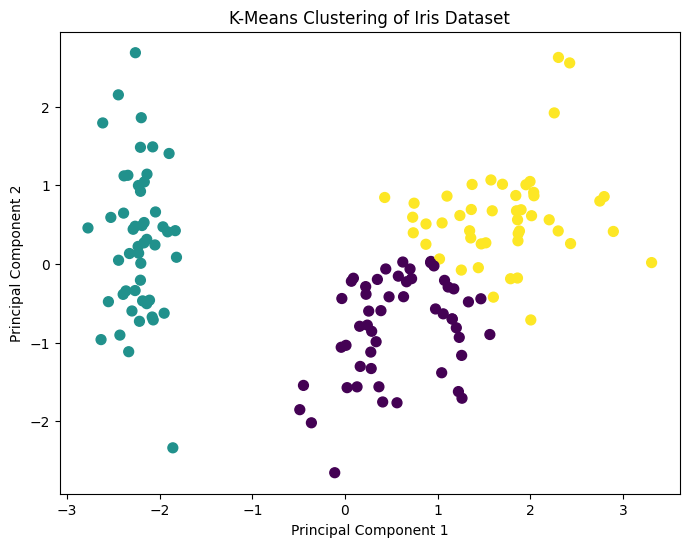

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of Iris Dataset")

plt.show()

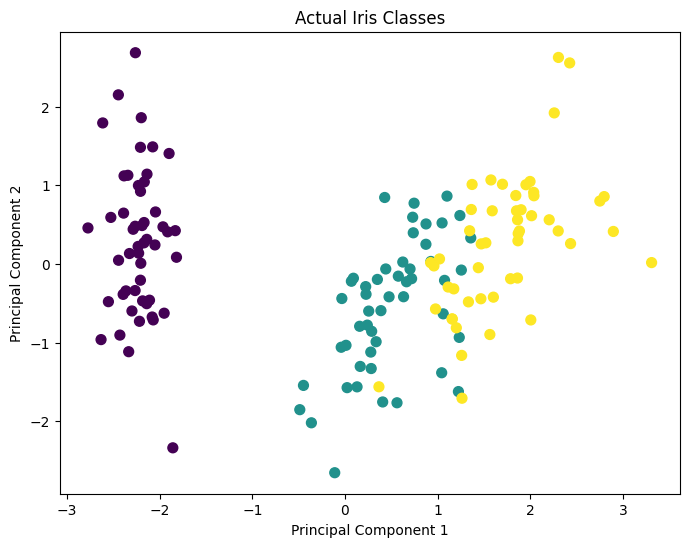

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Actual Iris Classes")

plt.show()

In [9]:
comparison = pd.crosstab(
    pd.Series(y, name="True Label"),
    pd.Series(clusters, name="K-Means Cluster")
)

print(comparison)

K-Means Cluster   0   1   2
True Label                 
0                 0  50   0
1                39   0  11
2                14   0  36


In [10]:
comparison_df = pd.DataFrame({
    "True Class": iris.target_names[y],
    "Predicted Cluster": clusters
})

comparison_df.head(20)

,True Class,Predicted Cluster
0,setosa,1
1,setosa,1
2,setosa,1
3,setosa,1
4,setosa,1
5,setosa,1
6,setosa,1
7,setosa,1
8,setosa,1
9,setosa,1


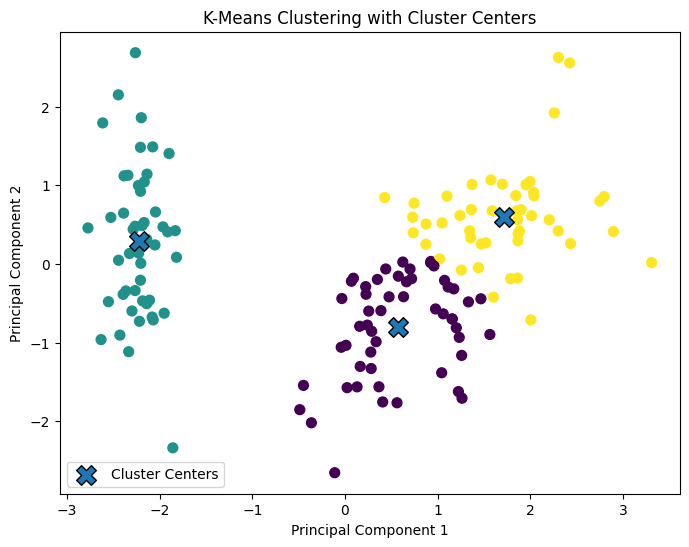

In [11]:
centers = kmeans.cluster_centers_

centers_pca = pca.transform(centers)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker="X",
    s=200,
    edgecolor="black",
    label="Cluster Centers"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering with Cluster Centers")
plt.legend()

plt.show()

Conclusion:
K-Means clustering was successfully applied to the Iris dataset with k=3. PCA was used to reduce the original four-dimensional feature space to two principal components for visualization. The resulting scatter plot shows that the Iris samples form three major groups corresponding broadly to the three Iris species. The comparison between K-Means clusters and the actual labels demonstrates how unsupervised learning can discover natural groupings in data without using the class labels during training.